# 02 - Regressao Linear

## Conceito
A regressao linear modela a relacao entre uma variavel alvo continua (y) e
uma ou mais variaveis explicativas (X) ajustando uma reta (ou hiperplano):

    y = b0 + b1*x1 + b2*x2 + ... + bn*xn + erro

O ajuste minimiza a soma dos quadrados dos residuos (minimos quadrados).

## Metricas tipicas
- MSE (erro quadratico medio): penaliza mais erros grandes
- RMSE: mesma unidade de y, mais interpretavel
- MAE: menos sensivel a outliers
- R2: proporcao da variancia explicada (1 e perfeito, 0 e igual a media)
- R2 ajustado: penaliza numero de features

## Suposicoes
- Relacao linear entre X e y
- Residuos com media zero, variancia constante (homocedasticidade)
- Independencia dos erros
- Ausencia de multicolinearidade forte

## Quando usar
- Alvo continuo
- Relacao aproximadamente linear
- Precisa de interpretabilidade (coeficientes tem significado)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Dataset diabetes: alvo continuo (progressao da doenca)
dados = load_diabetes()
X, y = dados.data, dados.target # type: ignore

print("X:", X.shape)
print("y:", y.shape)
print("Features:", dados.feature_names) # type: ignore

X: (442, 10)
y: (442,)
Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Coeficientes e intercepto
print("Intercepto:", round(modelo.intercept_, 3)) # type: ignore
for nome, coef in zip(dados.feature_names, modelo.coef_): # type: ignore
    print(f"  {nome:<10}: {coef:>10.3f}")

Intercepto: 151.346
  age       :     37.904
  sex       :   -241.964
  bmi       :    542.429
  bp        :    347.704
  s1        :   -931.489
  s2        :    518.062
  s3        :    163.420
  s4        :    275.318
  s5        :    736.199
  s6        :     48.671


In [3]:
y_pred = modelo.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE :", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("MAE :", round(mae, 2))
print("R2  :", round(r2, 3))

MSE : 2900.19
RMSE: 53.85
MAE : 42.79
R2  : 0.453


## Visualizando o ajuste

Em problemas com uma unica feature, plotamos a reta ajustada. Com multiplas,
comparamos valores previstos com reais.

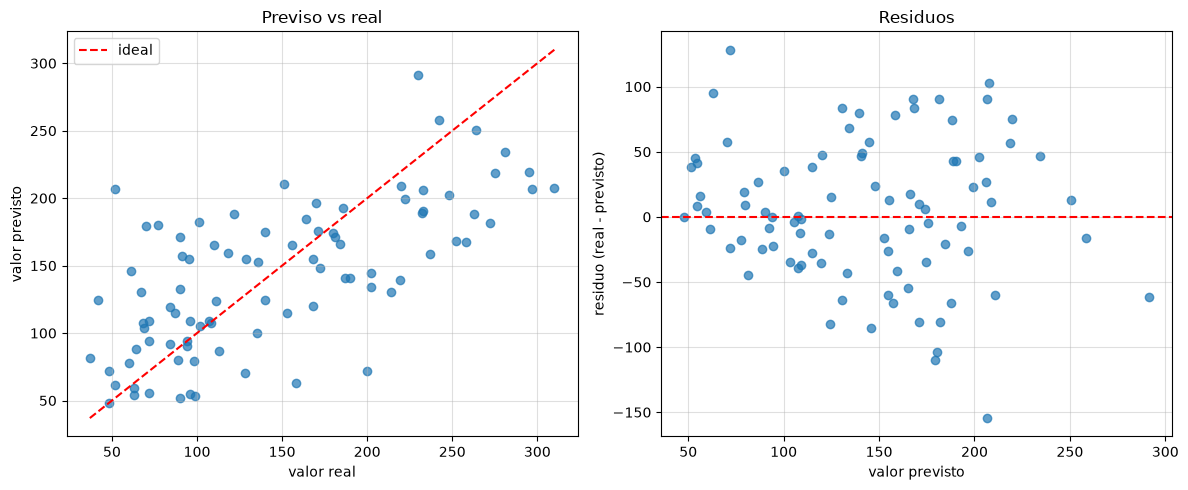

In [4]:
# Previso vs real
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, y_pred, alpha=0.7)
limites = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(limites, limites, "r--", label="ideal")
axes[0].set_xlabel("valor real")
axes[0].set_ylabel("valor previsto")
axes[0].set_title("Previso vs real")
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Residuos
residuos = y_test - y_pred
axes[1].scatter(y_pred, residuos, alpha=0.7)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("valor previsto")
axes[1].set_ylabel("residuo (real - previsto)")
axes[1].set_title("Residuos")
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

## Regressao com uma unica feature

Para visualizar a reta ajustada, usamos apenas uma feature.

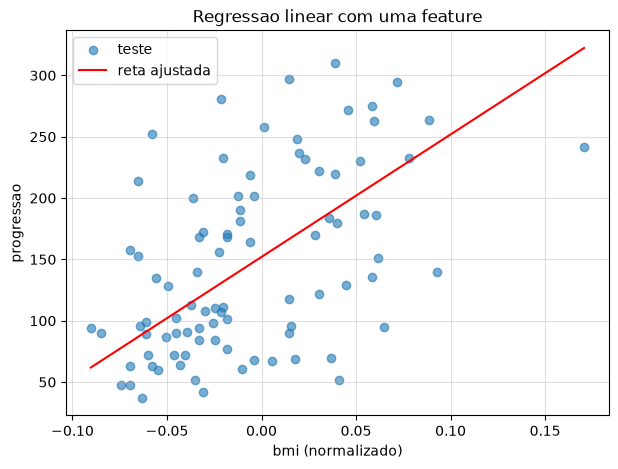

Coeficiente: 998.58
Intercepto : 152.0
R2 teste   : 0.233


In [5]:
# Usando apenas o BMI (indice de massa corporal) como exemplo
idx_bmi = dados.feature_names.index("bmi") # type: ignore
X_simples = X[:, idx_bmi].reshape(-1, 1)

X_tr, X_te, y_tr, y_te = train_test_split(X_simples, y, test_size=0.2, random_state=42)

modelo_simples = LinearRegression().fit(X_tr, y_tr)

# Grade para plotar a reta
x_grade = np.linspace(X_simples.min(), X_simples.max(), 100).reshape(-1, 1)
y_grade = modelo_simples.predict(x_grade)

plt.figure(figsize=(7, 5))
plt.scatter(X_te, y_te, alpha=0.6, label="teste")
plt.plot(x_grade, y_grade, color="red", label="reta ajustada")
plt.xlabel("bmi (normalizado)")
plt.ylabel("progressao")
plt.title("Regressao linear com uma feature")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

print("Coeficiente:", round(modelo_simples.coef_[0], 2))
print("Intercepto :", round(modelo_simples.intercept_, 2)) # type: ignore
print("R2 teste   :", round(r2_score(y_te, modelo_simples.predict(X_te)), 3))

## Regularizacao

Ridge (L2) e Lasso (L1) adicionam penalidade aos coeficientes para reduzir
overfitting. Lasso tambem faz selecao de features (zera coeficientes).

In [6]:
from sklearn.linear_model import Ridge, Lasso

for nome, modelo in [("Linear", LinearRegression()),
                     ("Ridge", Ridge(alpha=1.0)),
                     ("Lasso", Lasso(alpha=0.1, max_iter=10000))]:
    modelo.fit(X_train, y_train)
    r2 = r2_score(y_test, modelo.predict(X_test))
    print(f"{nome:<8} R2 = {r2:.3f}")

Linear   R2 = 0.453
Ridge    R2 = 0.419
Lasso    R2 = 0.472


## Exercicios

1. Treine uma regressao linear no dataset diabetes usando apenas 3 features
   e compare o R2 com o modelo completo.
2. Ajuste o hiperparametro alpha do Ridge em uma grade [0.01, 0.1, 1, 10, 100]
   e veja qual da o melhor R2 no conjunto de teste.
3. Plote os residuos contra cada feature e verifique se ha padrao.
4. Explique a diferenca entre MSE e MAE em termos de sensibilidade a outliers.